# 公式 o10 — Simple EGFR model（ルールベースモデリング）

> **出典（E-Cell4 公式）**: Examples / example04 — https://ecell4.e-cell.org/examples/example04.html
>
> EGF 受容体シグナルを**ルールベース**（BioNetGen 風の site/state 記法）で書く例。`EGFR(L, CR1, Y1068=U)` のように
> **結合サイトとリン酸化状態**を持つ分子を定義し、組合せ爆発を `get_model(is_netfree=True)` ＋ `expand()` で扱う。公式コードをそのまま移植。

In [1]:
import warnings; warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from ecell4.prelude import *

NA = 6.02e23; f = 1
Vo = f * 1.0e-10   # 細胞外体積 (L)
V = f * 3.0e-12    # 細胞質体積 (L)
EGF_init = 20 * 1e-9 * NA * Vo   # 20 nM のリガンド
EGFR_init, Grb2_init, Sos1_init = f*1.8e5, f*1.5e5, f*6.2e4
kp1=9.0e7/(NA*Vo); km1=0.06; kp2=1.0e7/(NA*V); km2=0.1; kp3=0.5; km3=4.505
kp4=1.5e6/(NA*V); km4=0.05; kp5=1.0e7/(NA*V); km5=0.06; deg=0.01

with reaction_rules():
    EGFR(L, CR1) + EGF(R) == EGFR(L^1, CR1).EGF(R^1) | (kp1, km1)                     # リガンド結合
    EGFR(L^_, CR1) + EGFR(L^_, CR1) == EGFR(L^_,CR1^1).EGFR(L^_,CR1^1) | (kp2, km2)   # 二量体化
    EGFR(CR1^_, Y1068=U) > EGFR(CR1^_, Y1068=P) | kp3                                  # 自己リン酸化
    EGFR(Y1068=P) > EGFR(Y1068=U) | km3
    EGFR(Y1068=P) + Grb2(SH2) == EGFR(Y1068=P^1).Grb2(SH2^1) | (kp4, km4)              # Grb2 リクルート
    Grb2(SH3) + Sos1(PxxP) == Grb2(SH3^1).Sos1(PxxP^1) | (kp5, km5)                    # Sos1 リクルート
m1 = get_model(is_netfree=True, effective=True)

y0 = {'EGF(R)': EGF_init, 'EGFR(L,CR1,Y1068=U)': EGFR_init,
      'Grb2(SH2,SH3)': Grb2_init, 'Sos1(PxxP)': Sos1_init}
m2 = m1.expand([Species(s) for s in y0.keys()])   # ルール -> 具体反応網へ展開
print('rule-based -> expanded species:', len(m2.list_species()))

rule-based -> expanded species: 22


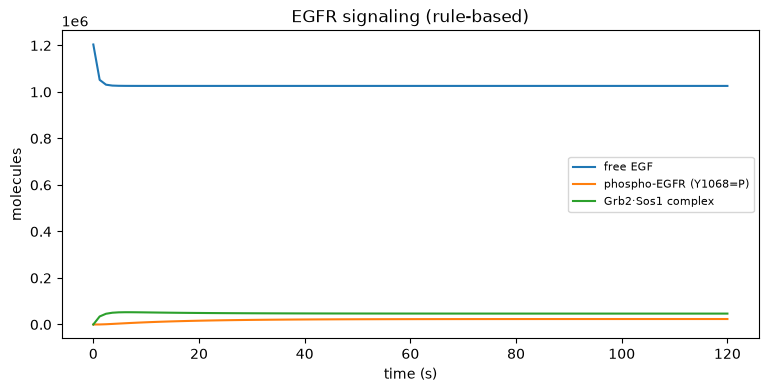

In [2]:
ret = run_simulation(120, model=m2, y0=y0,
                     species_list=['EGF(R)', 'EGFR(Y1068=P^_)', 'Grb2(SH2,SH3^1).Sos1(PxxP^1)'])
a = ret.as_array()
plt.figure(figsize=(9,4))
for i,lab in enumerate(['free EGF','phospho-EGFR (Y1068=P)','Grb2·Sos1 complex'],1):
    plt.plot(a[:,0], a[:,i], label=lab)
plt.xlabel('time (s)'); plt.ylabel('molecules'); plt.legend(fontsize=8); plt.title('EGFR signaling (rule-based)'); plt.show()

## 読み取り

EGF が受容体に結合 → 受容体二量体化 → 自己リン酸化（Y1068=P）→ アダプター Grb2 と Sos1 がリクルートされる、という
シグナル伝達の初期段階。**ルールベース**では、状態・結合の組合せ（この例で 22 種に展開）を数本のルールで表せる。

**要点（公式が教えたい機能）**:
- `EGFR(L, CR1, Y1068=U)` の**サイト（結合手）と状態**の記法、`^1` で結合、`.` で複合体、`^_` で「何かに結合済み」。
- `get_model(is_netfree=True)` でルールのまま保持し、`expand(...)` で必要な具体種へ展開して数値計算する。
- 組合せ爆発する翻訳後修飾・多量体化を、少数のルールで扱える（BioNetGen 的アプローチ）。